In [3]:
import pandas as pd
from utils import compare_poly, get_season
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
# Load the data
kpi_df = pd.read_feather('../data/kpi_df.feather').reset_index()
weather_df = pd.read_feather('../data/weather_burbank_airport.feather')

In [5]:
kpi_df.head()

,index,local_hour,total_kWh,session_count
0,0,2018-04-25 04:00:00-07:00,3.094930,1
1,1,2018-04-25 05:00:00-07:00,3.575657,1
2,2,2018-04-25 06:00:00-07:00,3.161296,3
3,3,2018-04-25 07:00:00-07:00,10.509661,8
4,4,2018-04-25 08:00:00-07:00,41.767757,22


In [6]:
weather_df.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0


In [7]:
len(weather_df)

29244

In [8]:
# Check for null values
missing_values = weather_df.isnull().sum()
missing_values

city                        0
timestamp                   0
temperature                25
cloud_cover                20
cloud_cover_description    20
pressure                    8
windspeed                  86
precipitation               0
felt_temperature           26
dtype: int64

Now we can handle the missing values. As it is time series data with one hour in between each record, it is likely that the values are very similar to the previous ones. That's why we fill missing values with the previous value.

In [9]:
# Fill missing values with the previous value
weather_df = weather_df.ffill()

In [10]:
# Round weather data timestamps to the nearest hour
weather_df["rounded_timestamp"] = weather_df["timestamp"].dt.ceil("h", ambiguous='NaT', nonexistent='NaT')

In [11]:
# Check if rounded timestamps are unique
weather_df["rounded_timestamp"].is_unique

False

In [12]:
# Analyze duplicates
duplicates = weather_df.groupby('rounded_timestamp').size()
non_unique_rounded_timestamps = duplicates[duplicates > 1].index
non_unique_rows_df = weather_df[weather_df['rounded_timestamp'].isin(non_unique_rounded_timestamps)]
non_unique_rows_df[['timestamp', 'rounded_timestamp']].head()

,timestamp,rounded_timestamp
150,2018-01-07 06:36:00-08:00,2018-01-07 07:00:00-08:00
151,2018-01-07 06:41:00-08:00,2018-01-07 07:00:00-08:00
152,2018-01-07 06:53:00-08:00,2018-01-07 07:00:00-08:00
153,2018-01-07 07:30:00-08:00,2018-01-07 08:00:00-08:00
154,2018-01-07 07:53:00-08:00,2018-01-07 08:00:00-08:00


In the weather data there are sometimes multiple measurements during the same hour. To avoid duplicates when joining the dataframes, we will only take the last measurement (minute 53) for each hour.

In [13]:
# Filter weather_df to only include rows where the minute is 53
weather_df_filtered = weather_df[weather_df['timestamp'].dt.minute == 53]
weather_df_filtered.head()

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0,2018-01-01 01:00:00-08:00
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0,2018-01-01 02:00:00-08:00
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0,2018-01-01 03:00:00-08:00
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0,2018-01-01 04:00:00-08:00
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0,2018-01-01 05:00:00-08:00


In [14]:
# Take only charging data from the beginnnig of 2018 to March 2020 (before the pandemic)
kpi_df = kpi_df[(kpi_df["local_hour"] >= "2018-01-01") & (kpi_df["local_hour"] < "2020-03-01")]

In [15]:
# Merge the two dataframes by timestamp
merged_df = kpi_df.merge(weather_df_filtered, left_on="local_hour", right_on="rounded_timestamp", how="left")

In [16]:
merged_df.head()

,index,local_hour,total_kWh,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,0,2018-04-25 04:00:00-07:00,3.094930,1,Burbank,2018-04-25 03:53:00-07:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0,2018-04-25 04:00:00-07:00
1,1,2018-04-25 05:00:00-07:00,3.575657,1,Burbank,2018-04-25 04:53:00-07:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0,2018-04-25 05:00:00-07:00
2,2,2018-04-25 06:00:00-07:00,3.161296,3,Burbank,2018-04-25 05:53:00-07:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0,2018-04-25 06:00:00-07:00
3,3,2018-04-25 07:00:00-07:00,10.509661,8,Burbank,2018-04-25 06:53:00-07:00,12.0,20.0,Fog,989.44,7.0,0.0,12.0,2018-04-25 07:00:00-07:00
4,4,2018-04-25 08:00:00-07:00,41.767757,22,Burbank,2018-04-25 07:53:00-07:00,12.0,26.0,Cloudy,990.10,6.0,0.0,12.0,2018-04-25 08:00:00-07:00


In [17]:
len(merged_df)

15692

In [18]:
# Check for null values
missing_values_merged = merged_df.isnull().sum()
missing_values_merged

index                       0
local_hour                  0
total_kWh                   1
session_count               0
city                       40
timestamp                  40
temperature                40
cloud_cover                40
cloud_cover_description    40
pressure                   40
windspeed                  40
precipitation              40
felt_temperature           40
rounded_timestamp          40
dtype: int64

There are 40 rows with missing weather data. We will drop these rows to be able to train the model.

In [19]:
# Drop rows with missing weather data 
merged_df = merged_df.dropna()

In [20]:
len(merged_df)

15651

In [21]:
merged_df.head()

,index,local_hour,total_kWh,session_count,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature,rounded_timestamp
0,0,2018-04-25 04:00:00-07:00,3.094930,1,Burbank,2018-04-25 03:53:00-07:00,12.0,26.0,Cloudy,989.11,11.0,0.0,12.0,2018-04-25 04:00:00-07:00
1,1,2018-04-25 05:00:00-07:00,3.575657,1,Burbank,2018-04-25 04:53:00-07:00,12.0,27.0,Mostly Cloudy,989.11,6.0,0.0,12.0,2018-04-25 05:00:00-07:00
2,2,2018-04-25 06:00:00-07:00,3.161296,3,Burbank,2018-04-25 05:53:00-07:00,12.0,28.0,Mostly Cloudy,989.11,9.0,0.0,12.0,2018-04-25 06:00:00-07:00
3,3,2018-04-25 07:00:00-07:00,10.509661,8,Burbank,2018-04-25 06:53:00-07:00,12.0,20.0,Fog,989.44,7.0,0.0,12.0,2018-04-25 07:00:00-07:00
4,4,2018-04-25 08:00:00-07:00,41.767757,22,Burbank,2018-04-25 07:53:00-07:00,12.0,26.0,Cloudy,990.10,6.0,0.0,12.0,2018-04-25 08:00:00-07:00


We have merged and cleaned the data. Now we have to prepare it for the machine learning model by encoding and normalizing the data.

In [22]:
model_df = merged_df.copy()

In [23]:
model_df["hour"] = model_df["local_hour"].dt.hour
model_df['is_weekend'] = model_df['local_hour'].dt.weekday >= 5
model_df["season"] = model_df["local_hour"].apply(get_season)

In [24]:
# Drop columns that are not needed for the model
model_df = model_df.drop(columns=["index", 'timestamp', 'rounded_timestamp', "city", "felt_temperature", "precipitation", "local_hour"])

In [25]:
# One hot encode categorical data
model_df = pd.get_dummies(model_df, columns=['season'], drop_first=True)
model_df = pd.get_dummies(model_df, columns=['cloud_cover_description'], drop_first=True)

In [26]:
cloud_cover_columns = [col for col in model_df.columns if col.startswith("cloud_cover_description")]

In [27]:
# Encode boolean columns
bool_cols = cloud_cover_columns + ["is_weekend", "season_Spring", "season_Summer", "season_Winter"]
model_df[bool_cols] = model_df[bool_cols].astype(int)

In [28]:
model_df.head()

,total_kWh,session_count,temperature,cloud_cover,pressure,windspeed,hour,is_weekend,season_Spring,season_Summer,...,cloud_cover_description_Light Rain,cloud_cover_description_Light Rain / Windy,cloud_cover_description_Mostly Cloudy,cloud_cover_description_Mostly Cloudy / Windy,cloud_cover_description_Partly Cloudy,cloud_cover_description_Partly Cloudy / Windy,cloud_cover_description_Rain,cloud_cover_description_Smoke,cloud_cover_description_T-Storm,cloud_cover_description_Thunder in the Vicinity
0,3.094930,1,12.0,26.0,989.11,11.0,4,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,3.575657,1,12.0,27.0,989.11,6.0,5,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,3.161296,3,12.0,28.0,989.11,9.0,6,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,10.509661,8,12.0,20.0,989.44,7.0,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,41.767757,22,12.0,26.0,990.10,6.0,8,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# Should be looked at closer in the kpi measurement

# remove negative total_kWh values
model_df = model_df[model_df['total_kWh'] >= 0]
# remove infinite total_kWh values
model_df = model_df[model_df['total_kWh'] != np.inf]

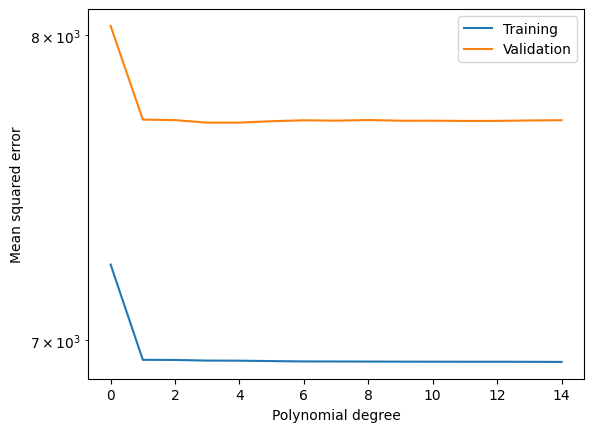

In [30]:
compare_poly(model_df, 'temperature', 'total_kWh', 15)

In [31]:
# Define the features and the target variable
X = model_df.drop(columns=["total_kWh"])
y = model_df["total_kWh"]

# Split the data into training and testing sets (80% train, 20% test)
X_train_initial, X_test, y_train_initial, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
#Data Scaling using MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_initial)
X_test_scaled = scaler.transform(X_test)

In [36]:
# --- K-Fold Cross-Validation Setup ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. Linear Regression Model ---
linear_model = LinearRegression()

# Lists to store evaluation metrics for each fold
linear_rmse_scores = []
linear_r2_scores = []

# Perform K-Fold Cross-Validation for Linear Regression
for train_index, val_index in kf.split(X_train_initial):
    X_train, X_val = X_train_scaled[train_index], X_train_scaled[val_index] 
    y_train, y_val = y_train_initial.iloc[train_index], y_train_initial.iloc[val_index]
    
    # Train the model
    linear_model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred_val = linear_model.predict(X_val)
    
    # Calculate RMSE and R² for the fold
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    # Store the metrics for later analysis
    linear_rmse_scores.append(rmse)
    linear_r2_scores.append(r2)

# Train the linear regression model on the entire training set
linear_model.fit(X_train_scaled, y_train_initial)

# Predict on the test set
y_pred_linear = linear_model.predict(X_test_scaled)

# Calculate MSE, RMSE, and R² on the test set for Linear Regression
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

# Print evaluation results
print("Linear Regression - Cross-validated RMSE: ", np.mean(linear_rmse_scores))
print("Linear Regression - Test RMSE: ", linear_rmse)
print("Linear Regression - Cross-validated R²: ", np.mean(linear_r2_scores))
print("Linear Regression - Test R²: ", linear_r2)

Linear Regression - Cross-validated RMSE:  42.78496012289548
Linear Regression - Test RMSE:  29.604948934970054
Linear Regression - Cross-validated R²:  0.7614173129068564
Linear Regression - Test R²:  0.8652575239378655


In [37]:
# --- 2. Neural Network Model ---
nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Lists to store evaluation metrics for each fold
nn_rmse_scores = []
nn_r2_scores = []

# Perform K-Fold Cross-Validation for Neural Network
for train_index, val_index in kf.split(X_train_initial):
    X_train, X_val = X_train_scaled[train_index], X_train_scaled[val_index] 
    y_train, y_val = y_train_initial.iloc[train_index], y_train_initial.iloc[val_index]
    
    # Train the model
    nn_model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred_val = nn_model.predict(X_val)
    
    # Calculate RMSE and R² for the fold
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2 = r2_score(y_val, y_pred_val)
    
    # Store the metrics for later analysis
    nn_rmse_scores.append(rmse)
    nn_r2_scores.append(r2)

# Train the neural network model on the entire training set
nn_model.fit(X_train_initial, y_train_initial)

# Predict on the test set
y_pred_nn = nn_model.predict(X_test)

# Calculate MSE, RMSE, and R² on the test set for Neural Network
nn_mse = mean_squared_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test, y_pred_nn)

print("Neural Network - Cross-validated RMSE: ", np.mean(nn_rmse_scores))
print("Neural Network - Test RMSE: ", nn_rmse)
print("Neural Network - Cross-validated R²: ", np.mean(nn_r2_scores))
print("Neural Network - Test R²: ", nn_r2)

/Users/BenBurkert/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-5D48J-wi-py3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/BenBurkert/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-5D48J-wi-py3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network - Cross-validated RMSE:  38.22061541733344
Neural Network - Test RMSE:  23.90924616346928
Neural Network - Cross-validated R²:  0.80825845664937
Neural Network - Test R²:  0.9121164365688363
